# Sephora Data - Reviews EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# List of file paths
file_paths = [
    "reviews_0-250_chunk_0.csv",
    "reviews_0-250_chunk_1.csv",
    "reviews_0-250_chunk_2.csv",
    "reviews_0-250_chunk_3.csv",
    "reviews_0-250_chunk_4.csv",
    "reviews_0-250_chunk_5.csv",
]

# Read and concatenate all files into a single DataFrame
combined_data = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)

# Check the combined data
print(combined_data.info())

# Save the combined data if needed
combined_data.to_csv("combined_reviews.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602130 entries, 0 to 602129
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                602130 non-null  int64  
 1   author_id                 602130 non-null  object 
 2   rating                    602130 non-null  int64  
 3   is_recommended            484644 non-null  float64
 4   helpfulness               270298 non-null  float64
 5   total_feedback_count      602130 non-null  int64  
 6   total_neg_feedback_count  602130 non-null  int64  
 7   total_pos_feedback_count  602130 non-null  int64  
 8   submission_time           602130 non-null  object 
 9   review_text               601131 non-null  object 
 10  review_title              435119 non-null  object 
 11  skin_tone                 496074 non-null  object 
 12  eye_color                 463642 non-null  object 
 13  skin_type                 527447 non-null  o

In [3]:
#Load dataset
product_data = pd.read_csv("product_info.csv",encoding="iso-8859-1")

In [4]:
combined_data.head()

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0


In [5]:
combined_data.describe(include='all')

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
count,602130.00000,602130,602130.000000,484644.000000,270298.000000,602130.000000,602130.000000,602130.000000,602130,601131,435119,496074,463642,527447,461049,602130,602130,602130,602130.000000
unique,NaN,378305,NaN,NaN,NaN,NaN,NaN,NaN,5317,508467,202373,14,6,4,7,250,249,60,NaN
top,NaN,1696370280,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21,review message autotest,Love it!,light,brown,combination,brown,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,Tatcha,NaN
freq,NaN,95,NaN,NaN,NaN,NaN,NaN,NaN,1451,13,3421,141402,243751,292308,218139,16138,16138,40681,NaN
mean,301064.50000,NaN,4.311838,0.837922,0.769722,3.660661,0.765473,2.895189,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.723937
std,173820.10313,NaN,1.143692,0.368522,0.319103,25.848330,4.968115,22.628880,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.743990
min,0.00000,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000
25%,150532.25000,NaN,4.000000,1.000000,0.666667,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.500000
50%,301064.50000,NaN,5.000000,1.000000,0.944444,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.000000
75%,451596.75000,NaN,5.000000,1.000000,1.000000,3.000000,0.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.000000


In [6]:
data = combined_data

# Check for missing values and their percentage
missing_values = data.isnull().sum()
missing_percentage = (missing_values / len(data)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
}).sort_values(by='Percentage (%)', ascending=False)

print("Missing Values Summary:")
print(missing_summary)


# Unique values for categorical columns
categorical_columns = ['is_recommended', 'skin_tone', 'eye_color', 'hair_color', 'skin_type']
for col in categorical_columns:
    print(f"\nUnique values in {col}:")
    print(data[col].unique())

Missing Values Summary:
                          Missing Values  Percentage (%)
helpfulness                       331832       55.109694
review_title                      167011       27.736701
hair_color                        141081       23.430322
eye_color                         138488       22.999684
is_recommended                    117486       19.511733
skin_tone                         106056       17.613472
skin_type                          74683       12.403136
review_text                          999        0.165911
brand_name                             0        0.000000
product_name                           0        0.000000
product_id                             0        0.000000
Unnamed: 0                             0        0.000000
author_id                              0        0.000000
submission_time                        0        0.000000
total_pos_feedback_count               0        0.000000
total_neg_feedback_count               0        0.000000
total_f

### We will have to deal with rows which have missing hair_color, eye_color, skin_tone, skin_type because our recommendation system heavily relies on the ratings for the particular hair or skin type.

In [7]:
# Count rows where all 4 columns are missing (AND condition)
all_missing_count = data[
    data[['skin_type', 'skin_tone', 'hair_color', 'eye_color']].isnull().all(axis=1)
].shape[0]

print(f"Number of rows where all skin_type, skin_tone, hair_color, and eye_color are missing: {all_missing_count}")

Number of rows where all skin_type, skin_tone, hair_color, and eye_color are missing: 70721


### There are 70721 rows with all missing features

In [8]:
# Count rows where any of the 4 columns are missing (OR condition)
any_missing_count = data[
    data[['skin_type', 'skin_tone', 'hair_color', 'eye_color']].isnull().any(axis=1)
].shape[0]

print(f"Number of rows where any of skin_type, skin_tone, hair_color, or eye_color is missing: {any_missing_count}")

Number of rows where any of skin_type, skin_tone, hair_color, or eye_color is missing: 150871


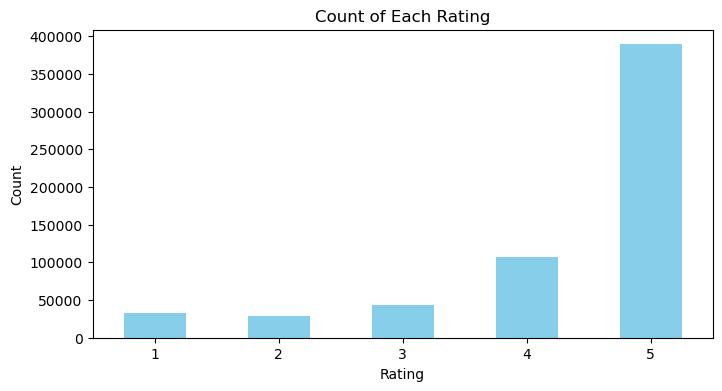

In [9]:
# Count the occurrences of each rating
rating_counts = data['rating'].value_counts().sort_index()

# Plot the counts
plt.figure(figsize=(8, 4))
rating_counts.plot(kind='bar', color='skyblue')
plt.title('Count of Each Rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

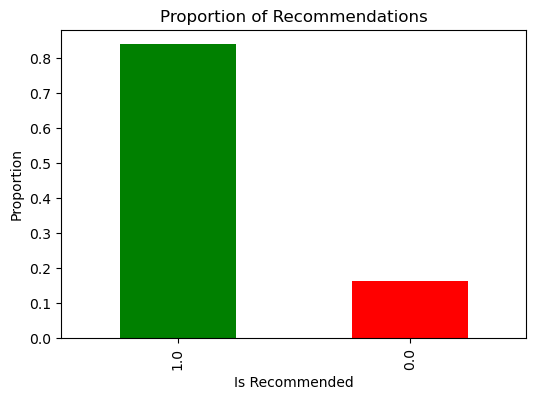

In [10]:
# Proportion of recommended reviews
plt.figure(figsize=(6, 4))
data['is_recommended'].value_counts(normalize=True).plot(kind='bar', color=['green', 'red'])
plt.title('Proportion of Recommendations')
plt.xlabel('Is Recommended')
plt.ylabel('Proportion')
plt.show()

In [11]:
brand_recommendations = data.groupby('brand_name')['is_recommended'].value_counts(normalize=True).unstack().fillna(0)

# To see the proportion of 'is_recommended' for each brand
brand_recommendations['Proportion Recommended'] = brand_recommendations[1]  # assuming 1 is the recommended value
brand_recommendations['Proportion Not Recommended'] = brand_recommendations[0]  # assuming 0 is the not recommended value

# Sort the brands by the highest number of recommended products
recommended_counts = data.groupby('brand_name')['is_recommended'].sum()
recommended_counts_sorted = recommended_counts.sort_values(ascending=False)

# Display the brand recommendation proportions and the brands with the highest recommendations
print("Proportion of Recommendations by Brand:")
print(brand_recommendations[['Proportion Recommended', 'Proportion Not Recommended']])

print("\nBrands with the Highest Number of Recommended Products:")
print(recommended_counts_sorted)

Proportion of Recommendations by Brand:
is_recommended             Proportion Recommended  Proportion Not Recommended
brand_name                                                                   
Algenist                                 0.876846                    0.123154
Biossance                                0.825057                    0.174943
Bobbi Brown                              0.936987                    0.063013
CLINIQUE                                 0.868543                    0.131457
Caudalie                                 0.839504                    0.160496
Charlotte Tilbury                        0.881912                    0.118088
Clarins                                  0.865723                    0.134277
Dermalogica                              0.943396                    0.056604
Dior                                     0.874038                    0.125962
Dr. Brandt Skincare                      0.932603                    0.067397
Dr. Dennis Gross Skincar

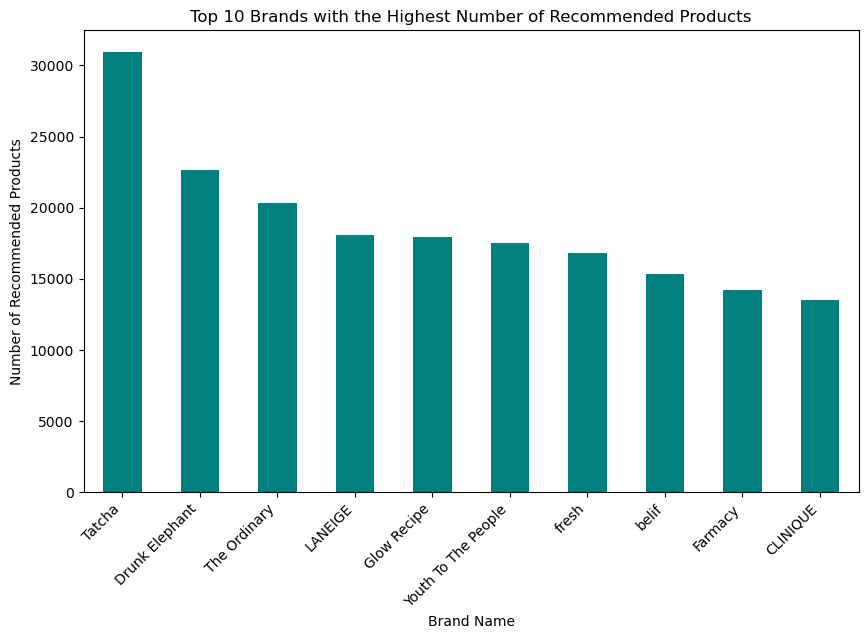

In [12]:
# Get the count of recommended products for each brand
recommended_counts = data.groupby('brand_name')['is_recommended'].sum()

# Sort the brands by the highest number of recommended products
recommended_counts_sorted = recommended_counts.sort_values(ascending=False).head(10)

# Plot the top 10 brands with the highest number of recommended products
plt.figure(figsize=(10, 6))
recommended_counts_sorted.plot(kind='bar', color='teal')
plt.title('Top 10 Brands with the Highest Number of Recommended Products')
plt.xlabel('Brand Name')
plt.ylabel('Number of Recommended Products')
plt.xticks(rotation=45, ha='right')
plt.show()

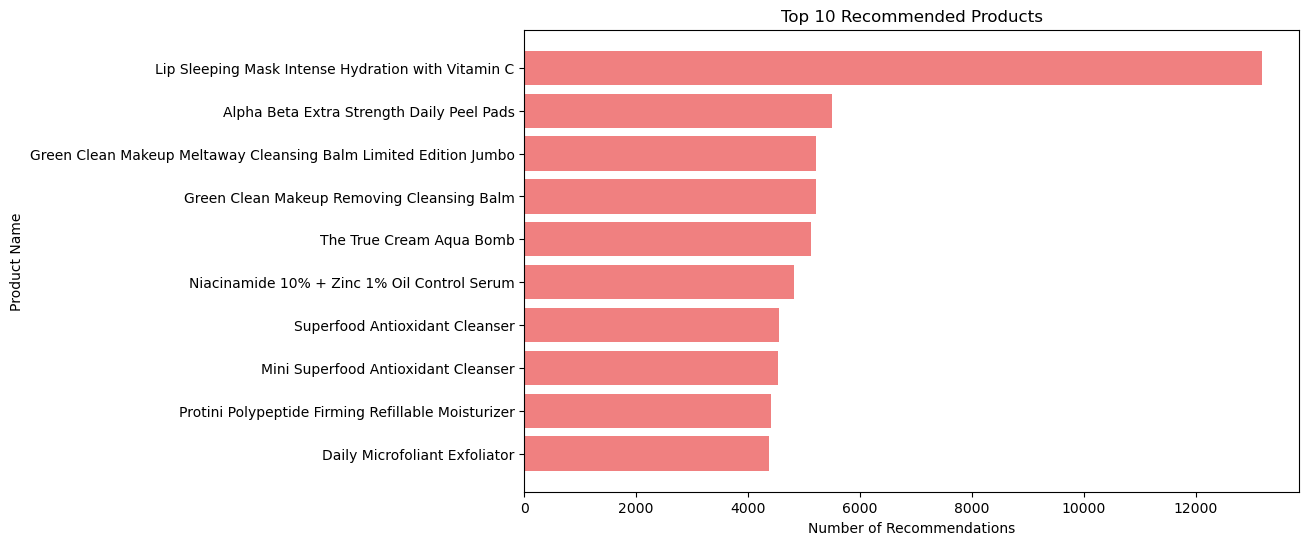

In [13]:
# Get the count of recommended products for each product_id
recommended_product_counts = data.groupby('product_id')['is_recommended'].sum()

# Sort the products by the highest number of recommended products
top_10_recommended_products = recommended_product_counts.sort_values(ascending=False).head(10)

# Merge with product_data to get the product names or additional details for better display
top_10_recommended_products_details = pd.merge(top_10_recommended_products, 
                                               product_data[['product_id', 'product_name']], 
                                               on='product_id', how='left')

# Plot the top 10 recommended products
plt.figure(figsize=(10, 6))
plt.barh(top_10_recommended_products_details['product_name'], top_10_recommended_products_details['is_recommended'], color='lightcoral')
plt.title('Top 10 Recommended Products')
plt.xlabel('Number of Recommendations')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()  # To display the highest recommended products at the top
plt.show()

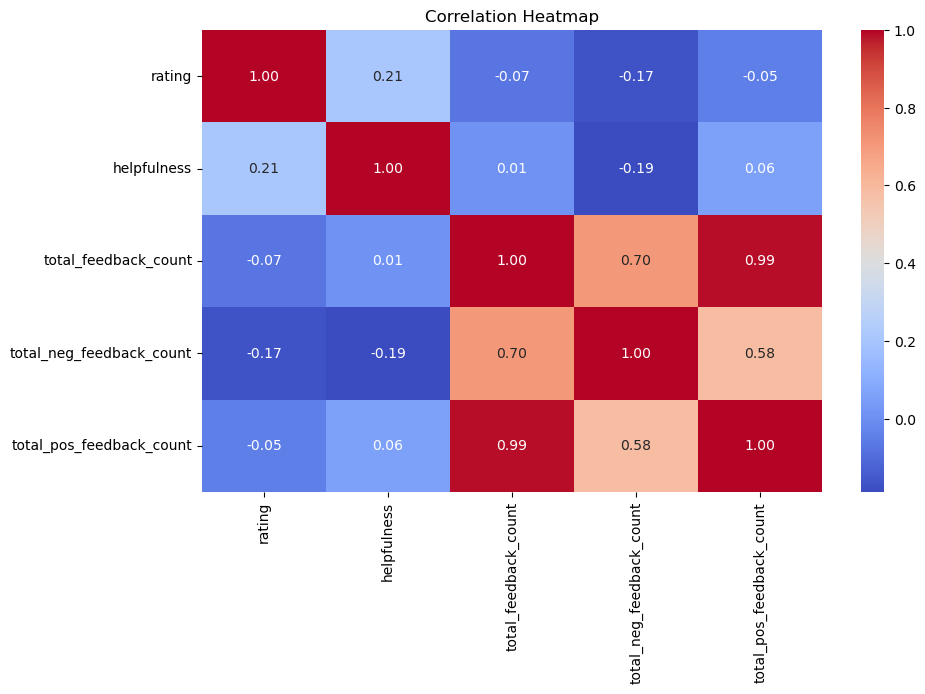

In [14]:
# Correlation heatmap for numeric features
numeric_columns = ['rating', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count']
plt.figure(figsize=(10, 6))
sns.heatmap(data[numeric_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

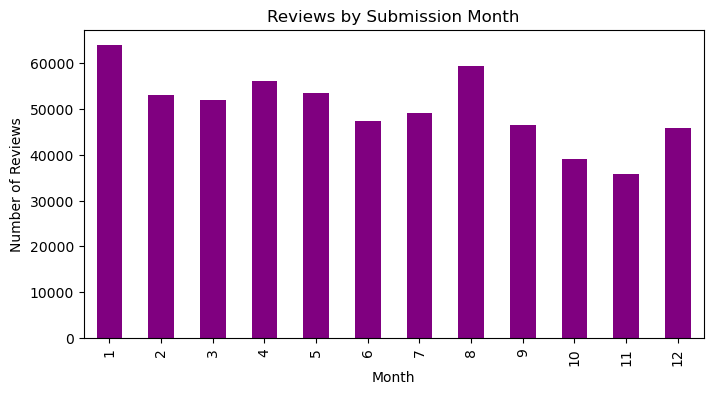

In [15]:
# Time analysis for submission time
data['submission_time'] = pd.to_datetime(data['submission_time'])
data['submission_month'] = data['submission_time'].dt.month

plt.figure(figsize=(8, 4))
data['submission_month'].value_counts().sort_index().plot(kind='bar', color='purple')
plt.title('Reviews by Submission Month')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.show()

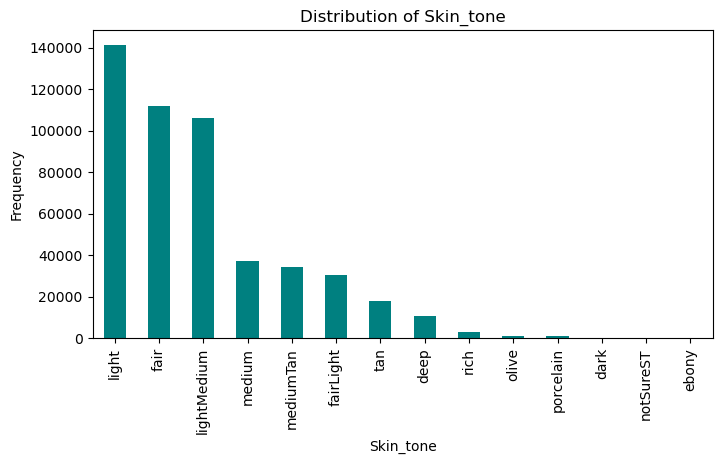

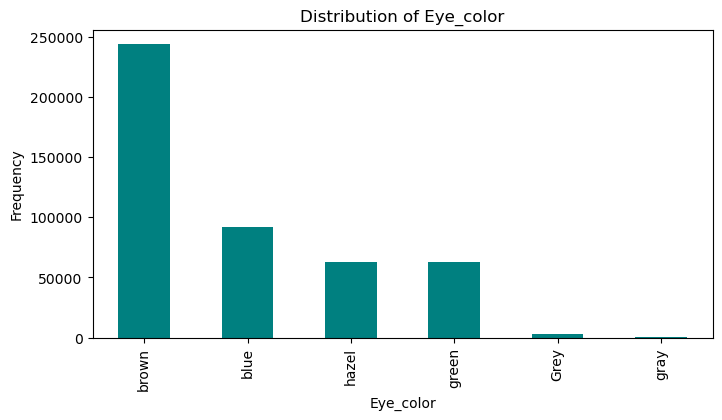

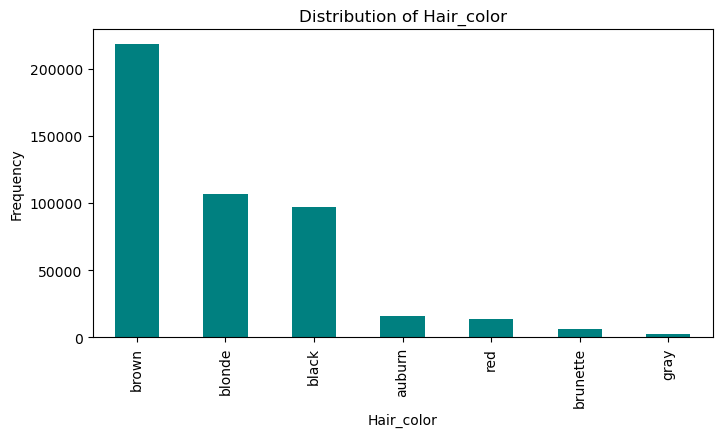

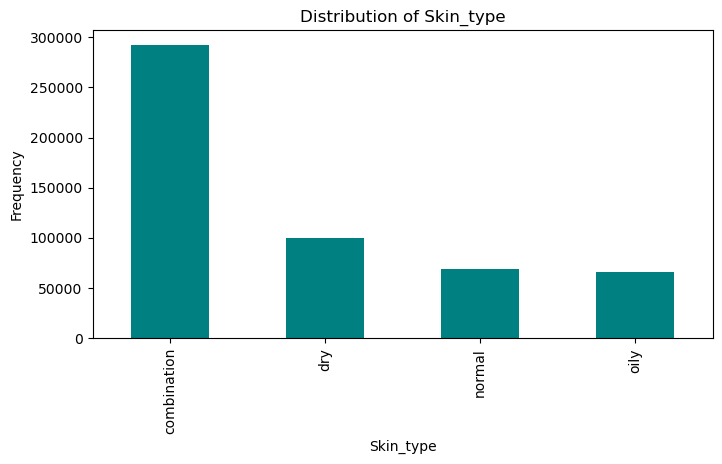

In [16]:
# Distribution of skin tone, eye color, hair color, and skin type
for col in ['skin_tone', 'eye_color', 'hair_color', 'skin_type']:
    plt.figure(figsize=(8, 4))
    data[col].value_counts().plot(kind='bar', color='teal')
    plt.title(f'Distribution of {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Frequency')
    plt.show()

In [17]:
# Group by product_id and aggregate feedback counts, keeping product_name and brand_name
feedback_summary = data.groupby(['product_id', 'product_name', 'brand_name']).agg(
    total_feedback_count=('total_feedback_count', 'sum'),
    total_positive_feedback_count=('total_pos_feedback_count', 'sum'),
    total_negative_feedback_count=('total_neg_feedback_count', 'sum')
).reset_index()

# Display the result
feedback_summary.head(20)

,product_id,product_name,brand_name,total_feedback_count,total_positive_feedback_count,total_negative_feedback_count
0,P114902,Goodbye Acne Max Complexion Correction Pads,Peter Thomas Roth,4202,3573,629
1,P12045,Grape Water Moisturizing Face Mist,Caudalie,5260,4209,1051
2,P122718,Exfoliating Face Scrub,CLINIQUE,1827,1470,357
3,P122774,All About Eyes Eye Cream,CLINIQUE,2683,2155,528
4,P122882,Clarifying Lotion 2,CLINIQUE,1964,1538,426
5,P122900,Dramatically Different Moisturizing Gel,CLINIQUE,4830,3663,1167
6,P12336,Rose Face Mask,fresh,4722,3616,1106
7,P12573,Intense Therapy Lip Balm SPF 25,Jack Black,4710,3628,1082
8,P126301,Take The Day Off Cleansing Balm Makeup Remover,CLINIQUE,8381,6413,1968
9,P139000,All About Clean Liquid Facial Soap,CLINIQUE,2539,1853,686


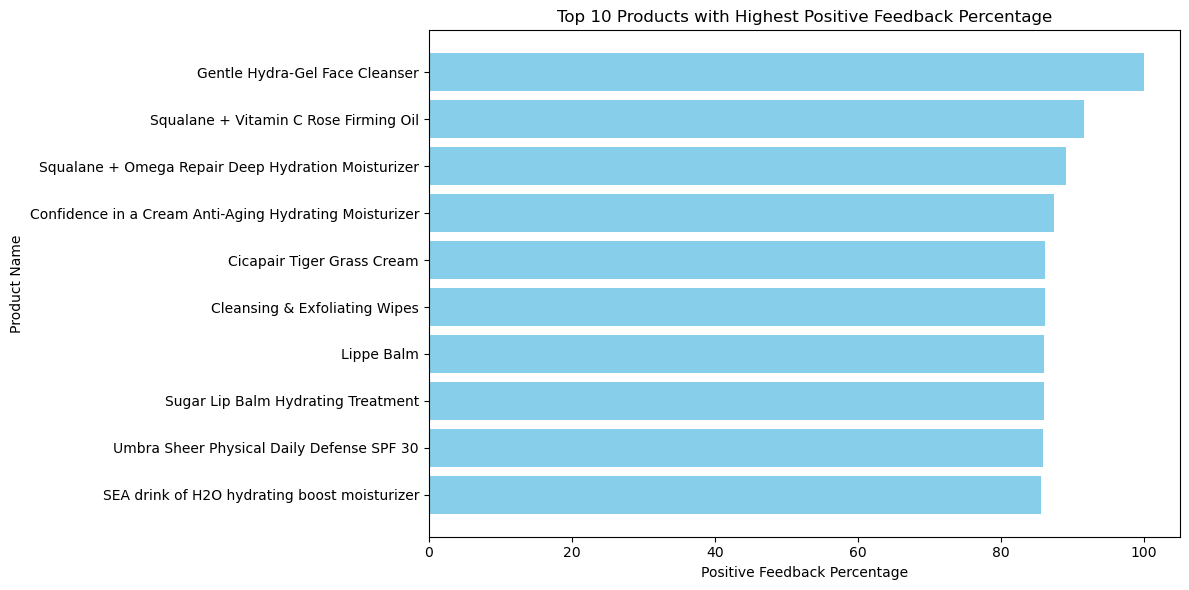

In [18]:
# Calculate the percentage of positive feedback for each product
feedback_summary['positive_feedback_percentage'] = (
    feedback_summary['total_positive_feedback_count'] / feedback_summary['total_feedback_count']
) * 100

# Sort by positive feedback percentage in descending order and select the top 10
top_10_positive_feedback = feedback_summary.sort_values(by='positive_feedback_percentage', ascending=False).head(10)

# Plot the top 10 products
plt.figure(figsize=(12, 6))
plt.barh(top_10_positive_feedback['product_name'], top_10_positive_feedback['positive_feedback_percentage'], color='skyblue')
plt.title('Top 10 Products with Highest Positive Feedback Percentage')
plt.xlabel('Positive Feedback Percentage')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()  # Invert y-axis to display highest at the top
plt.tight_layout()
plt.show()

### Feature Engineering - Classifying products as cheap/expensive based on price of each product grouped by tertiary category (119 unique categories)

In [19]:
# Merge the data with product_data to include tertiary_category and price_usd
merged_data = pd.merge(
    data, 
    product_data[['product_id', 'tertiary_category', 'price_usd']], 
    on='product_id', 
    how='left'
)

# Drop the redundant price_usd_x and keep price_usd_y (from product_data)
merged_data = merged_data.drop(columns=['price_usd_x'])

# Now we can safely use the 'price_usd_y' column for further analysis
merged_data.rename(columns={'price_usd_y': 'price_usd'}, inplace=True)

# Group by tertiary_category and calculate statistics for price_usd
category_price_stats = merged_data.groupby('tertiary_category').agg(
    min_price=('price_usd', 'min'),
    max_price=('price_usd', 'max'),
    std_price=('price_usd', 'std'),
    mean_price=('price_usd', 'mean'),
    median_price=('price_usd', 'median')
).reset_index()

# Display the result
category_price_stats.head(20)

,tertiary_category,min_price,max_price,std_price,mean_price,median_price
0,BB & CC Creams,44.00,52.0,3.265065,50.311045,52.0
1,Blemish & Acne Treatments,19.00,48.0,9.862036,25.716978,19.0
2,Exfoliators,26.00,125.0,31.571155,64.478160,65.0
3,Eye Creams & Treatments,10.99,72.0,17.016657,50.907692,57.0
4,Eye Masks,42.00,42.0,0.000000,42.000000,42.0
5,Face Masks,16.00,80.0,18.042242,42.508118,49.0
6,Face Oils,10.90,145.0,30.726896,60.558778,49.0
7,Face Serums,6.00,195.0,44.542777,63.107045,65.0
8,Face Sunscreen,16.00,50.0,10.964036,38.389447,38.0
9,Face Wash & Cleansers,5.99,60.0,12.957362,34.219144,38.0


### We will use median as a classifier due to skewed data (presence of outliers in the form of too expensive products)

In [20]:
merged_data.head()

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,...,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,submission_month,tertiary_category,price_usd
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,...,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,2,NaN,19.0
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,...,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,3,NaN,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,...,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,3,NaN,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,...,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,3,NaN,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",...,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,3,NaN,24.0


In [22]:
# Map 'median_price' from category_price_stats to merged_data based on 'tertiary_category'
merged_data['median_price'] = merged_data['tertiary_category'].map(
    category_price_stats.set_index('tertiary_category')['median_price']
)

merged_data.tail()

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,...,eye_color,skin_type,hair_color,product_id,product_name,brand_name,submission_month,tertiary_category,price_usd,median_price
602125,602125,7446977307,5,1.0,1.0,12,0,12,2020-12-17,I can’t say enough great things about this pro...,...,green,dry,blonde,P467602,Triple Algae Eye Renewal Balm Eye Cream,Algenist,12,Eye Creams & Treatments,68.0,57.0
602126,602126,1991973234,5,1.0,1.0,4,0,4,2020-12-17,I have been using this product for over 6 week...,...,brown,combination,black,P467602,Triple Algae Eye Renewal Balm Eye Cream,Algenist,12,Eye Creams & Treatments,68.0,57.0
602127,602127,1339171721,5,1.0,1.0,10,0,10,2020-12-17,I love the Triple Algae Eye Renewal Balm! Once...,...,hazel,dry,brown,P467602,Triple Algae Eye Renewal Balm Eye Cream,Algenist,12,Eye Creams & Treatments,68.0,57.0
602128,602128,1917233409,5,1.0,1.0,5,0,5,2020-12-17,This made the lines around my eyes so much bet...,...,hazel,combination,brown,P467602,Triple Algae Eye Renewal Balm Eye Cream,Algenist,12,Eye Creams & Treatments,68.0,57.0
602129,602129,1244540073,5,1.0,1.0,5,0,5,2020-12-17,"So rich & creamy, yet not greasy . . . It rea...",...,blue,dry,blonde,P467602,Triple Algae Eye Renewal Balm Eye Cream,Algenist,12,Eye Creams & Treatments,68.0,57.0


In [28]:
# Add a new column classifying the price with handling for missing median_price
merged_data['price_classification'] = merged_data.apply(
    lambda row: 'Affordable' if pd.notnull(row['median_price']) and row['price_usd'] < row['median_price'] 
    else ('Expensive' if pd.notnull(row['median_price']) else None),
    axis=1
)

merged_data.tail()

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,...,skin_type,hair_color,product_id,product_name,brand_name,submission_month,tertiary_category,price_usd,median_price,price_classification
602125,602125,7446977307,5,1.0,1.0,12,0,12,2020-12-17,I can’t say enough great things about this pro...,...,dry,blonde,P467602,Triple Algae Eye Renewal Balm Eye Cream,Algenist,12,Eye Creams & Treatments,68.0,57.0,Expensive
602126,602126,1991973234,5,1.0,1.0,4,0,4,2020-12-17,I have been using this product for over 6 week...,...,combination,black,P467602,Triple Algae Eye Renewal Balm Eye Cream,Algenist,12,Eye Creams & Treatments,68.0,57.0,Expensive
602127,602127,1339171721,5,1.0,1.0,10,0,10,2020-12-17,I love the Triple Algae Eye Renewal Balm! Once...,...,dry,brown,P467602,Triple Algae Eye Renewal Balm Eye Cream,Algenist,12,Eye Creams & Treatments,68.0,57.0,Expensive
602128,602128,1917233409,5,1.0,1.0,5,0,5,2020-12-17,This made the lines around my eyes so much bet...,...,combination,brown,P467602,Triple Algae Eye Renewal Balm Eye Cream,Algenist,12,Eye Creams & Treatments,68.0,57.0,Expensive
602129,602129,1244540073,5,1.0,1.0,5,0,5,2020-12-17,"So rich & creamy, yet not greasy . . . It rea...",...,dry,blonde,P467602,Triple Algae Eye Renewal Balm Eye Cream,Algenist,12,Eye Creams & Treatments,68.0,57.0,Expensive


### We have added a new feature price_classification which will classify the product as Affordable (price_usd < median_price) OR Expensive (price_usd > median_price)